# check the content produced by the summaries

In [287]:
import numpy as np
import os
import glob
from matplotlib import pyplot as plt
from src.evaluation import plotting
from src.evaluation.inference import Sampler
from IPython.display import Image, display


Seen 177 models
Found 4 with summaries
The best checkpoint is /data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__17_17_55/checkpoints/2026-08-18_23-21-15_model.pt
CUDA not avaliable, using CPU
CUDA not avaliable, using CPU
CUDA not avaliable, using CPU
CUDA not avaliable, using CPU


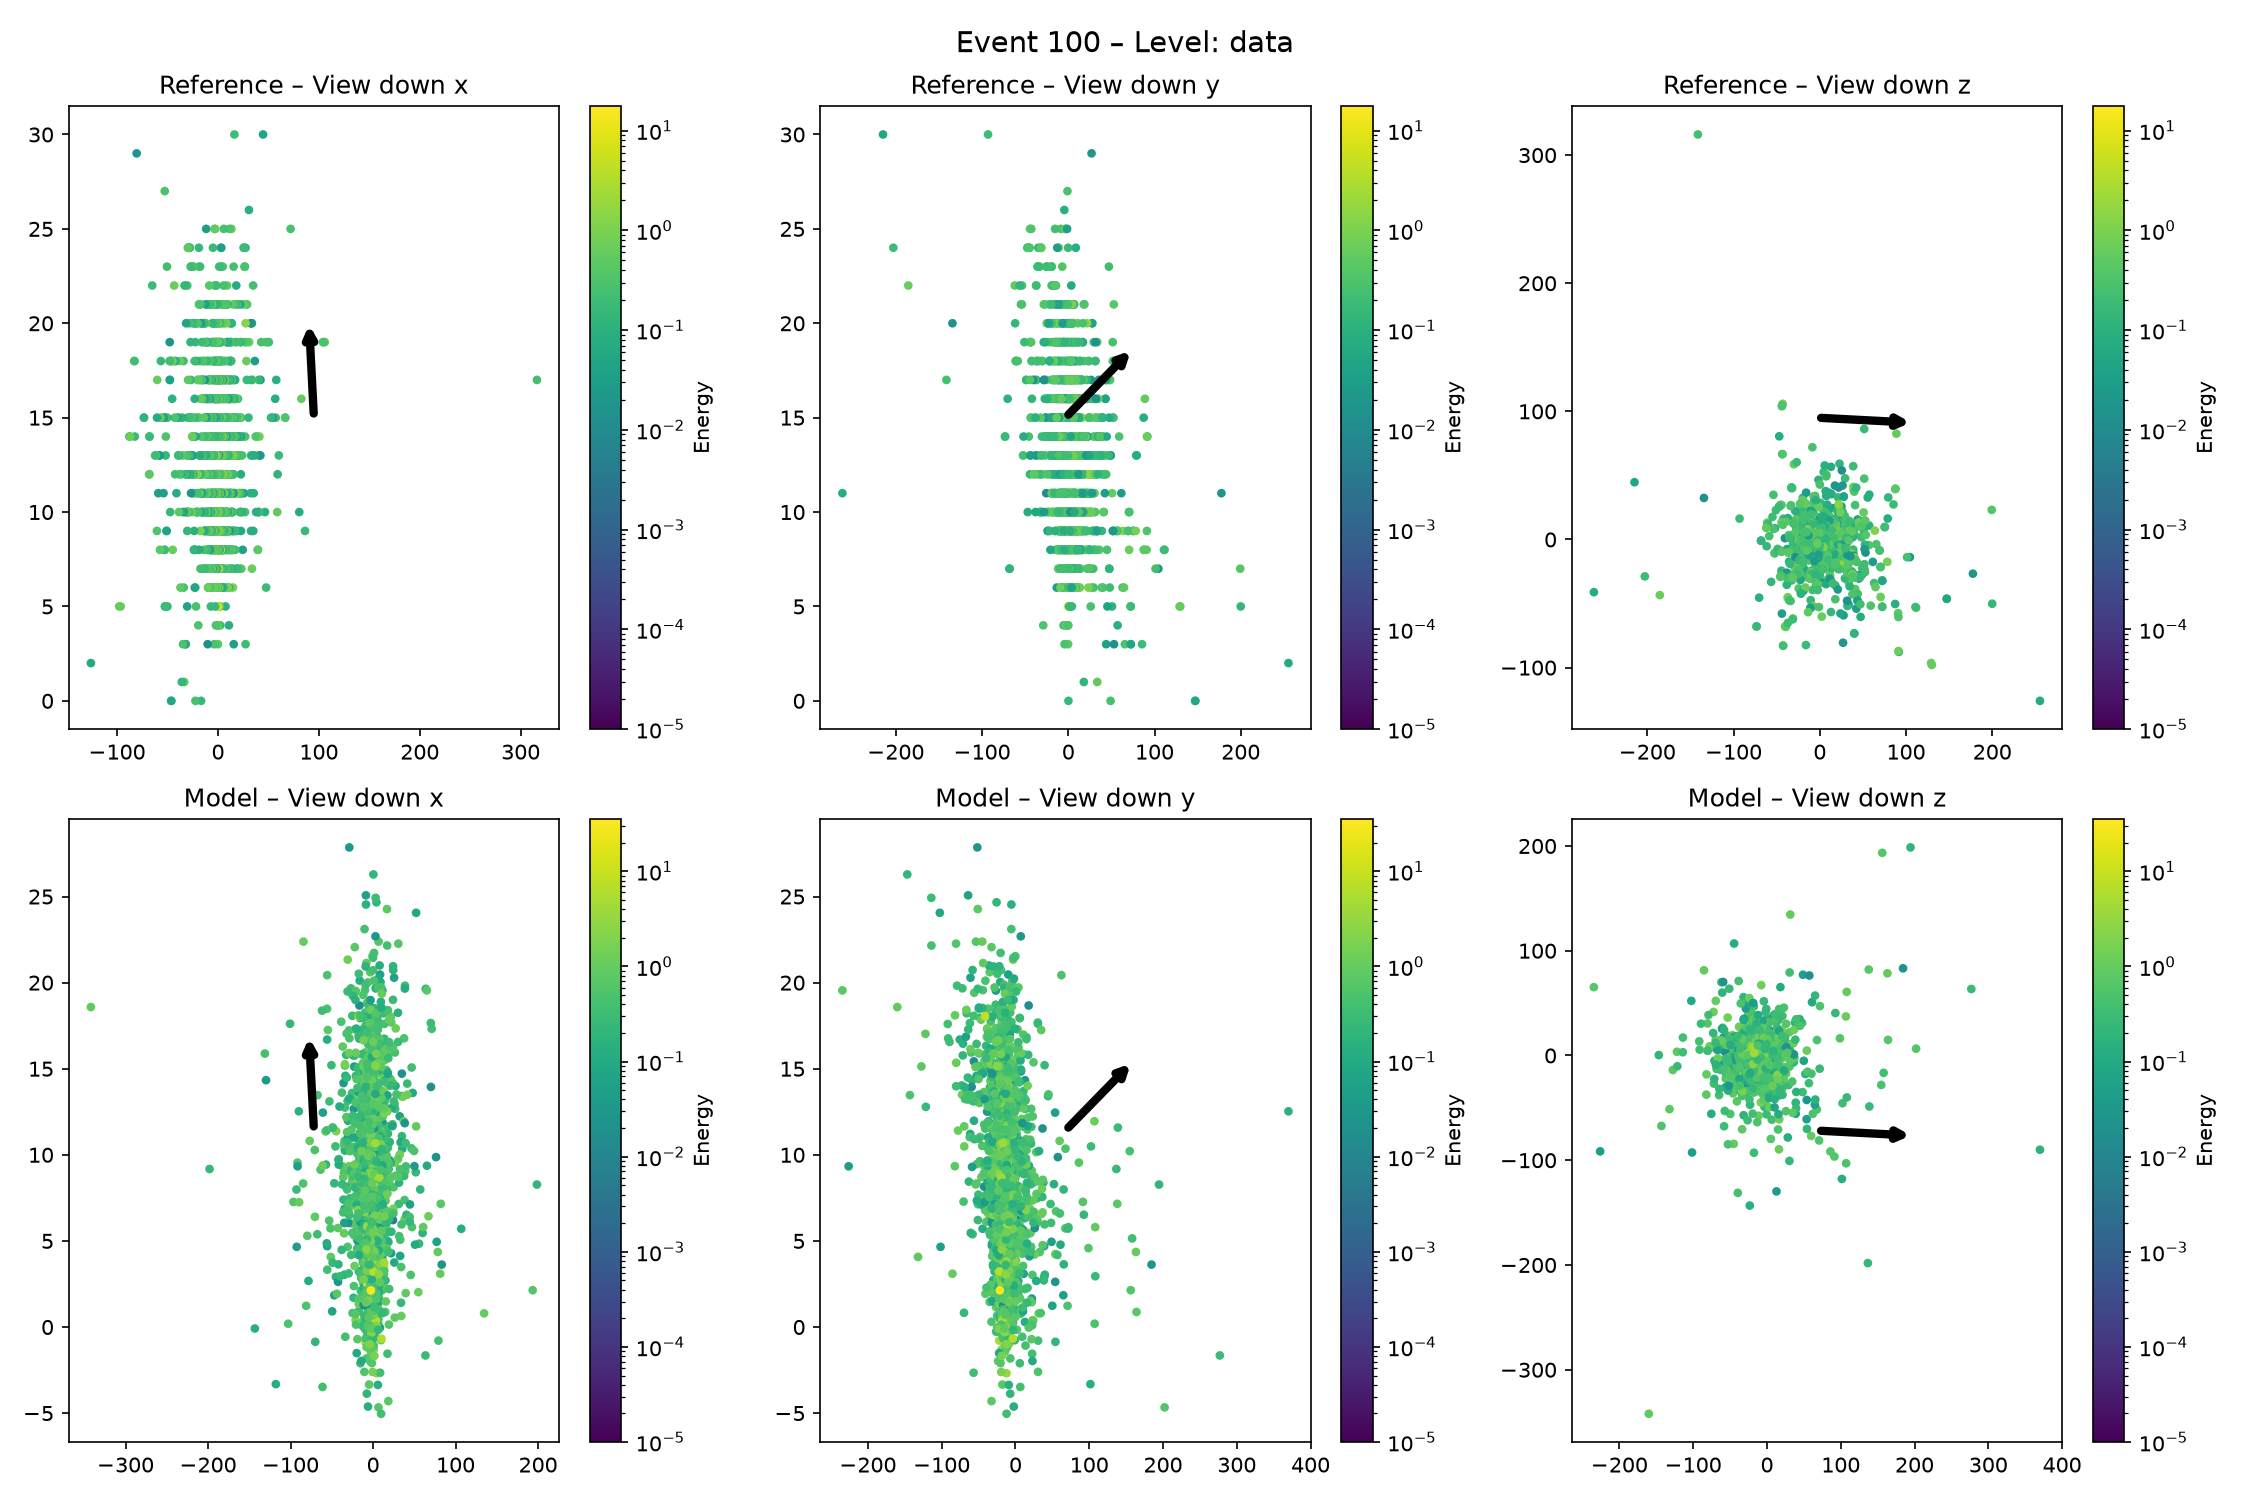

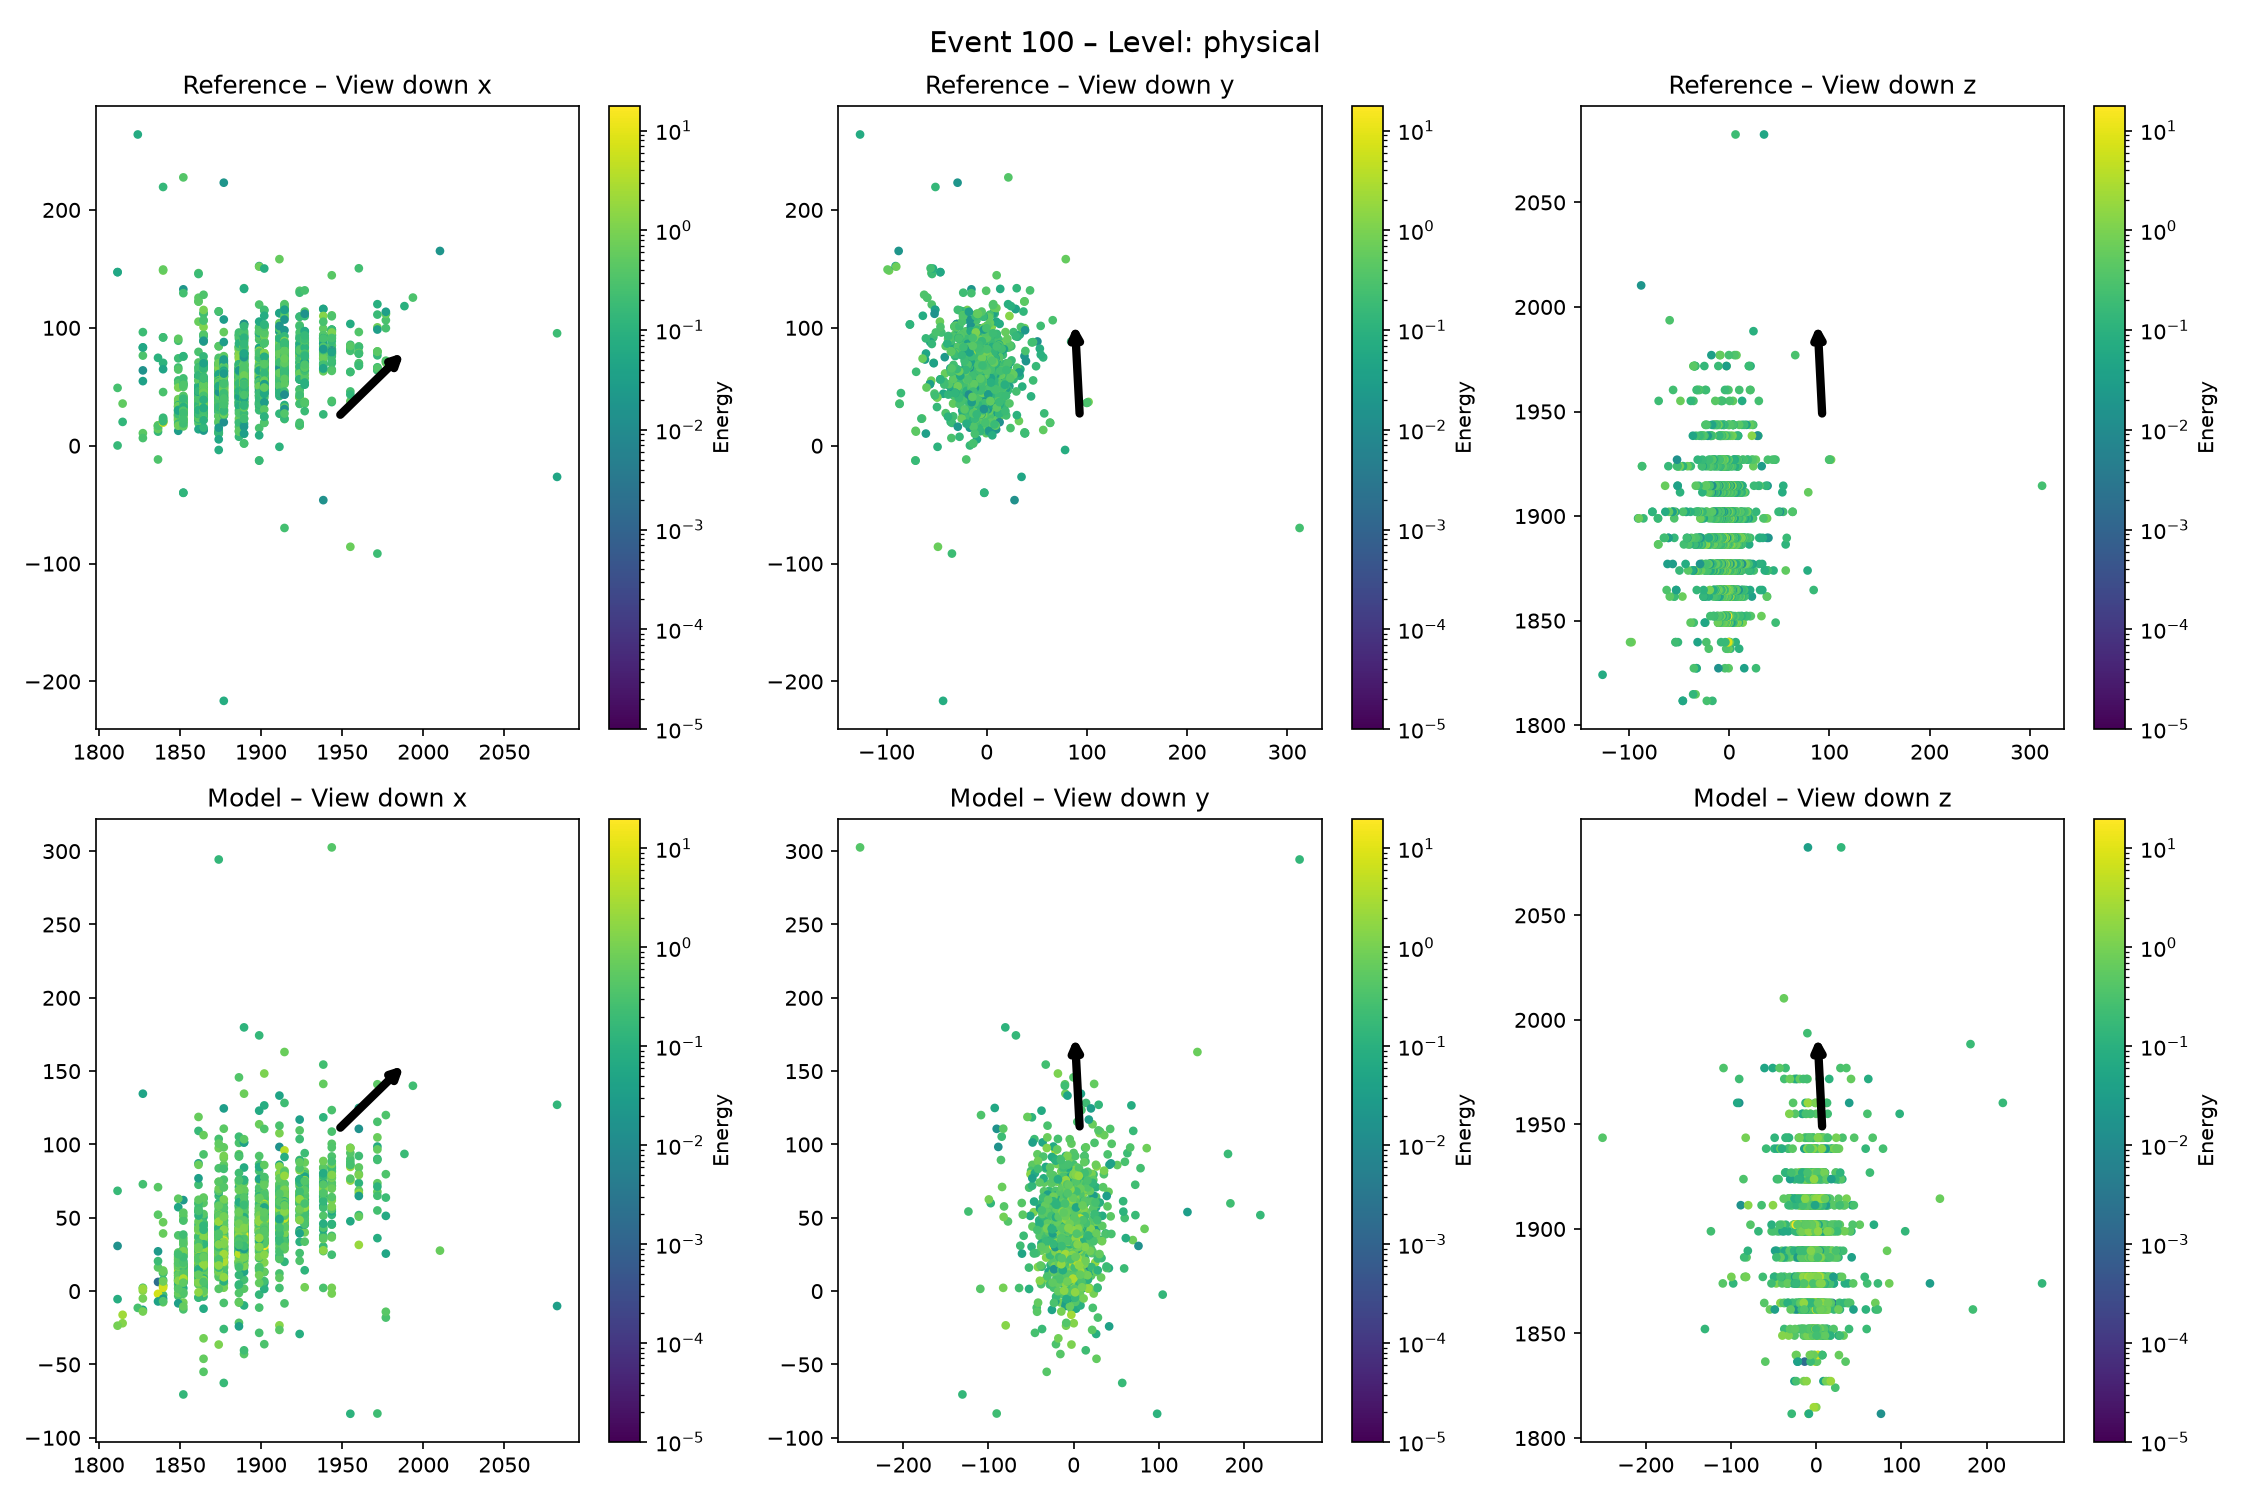

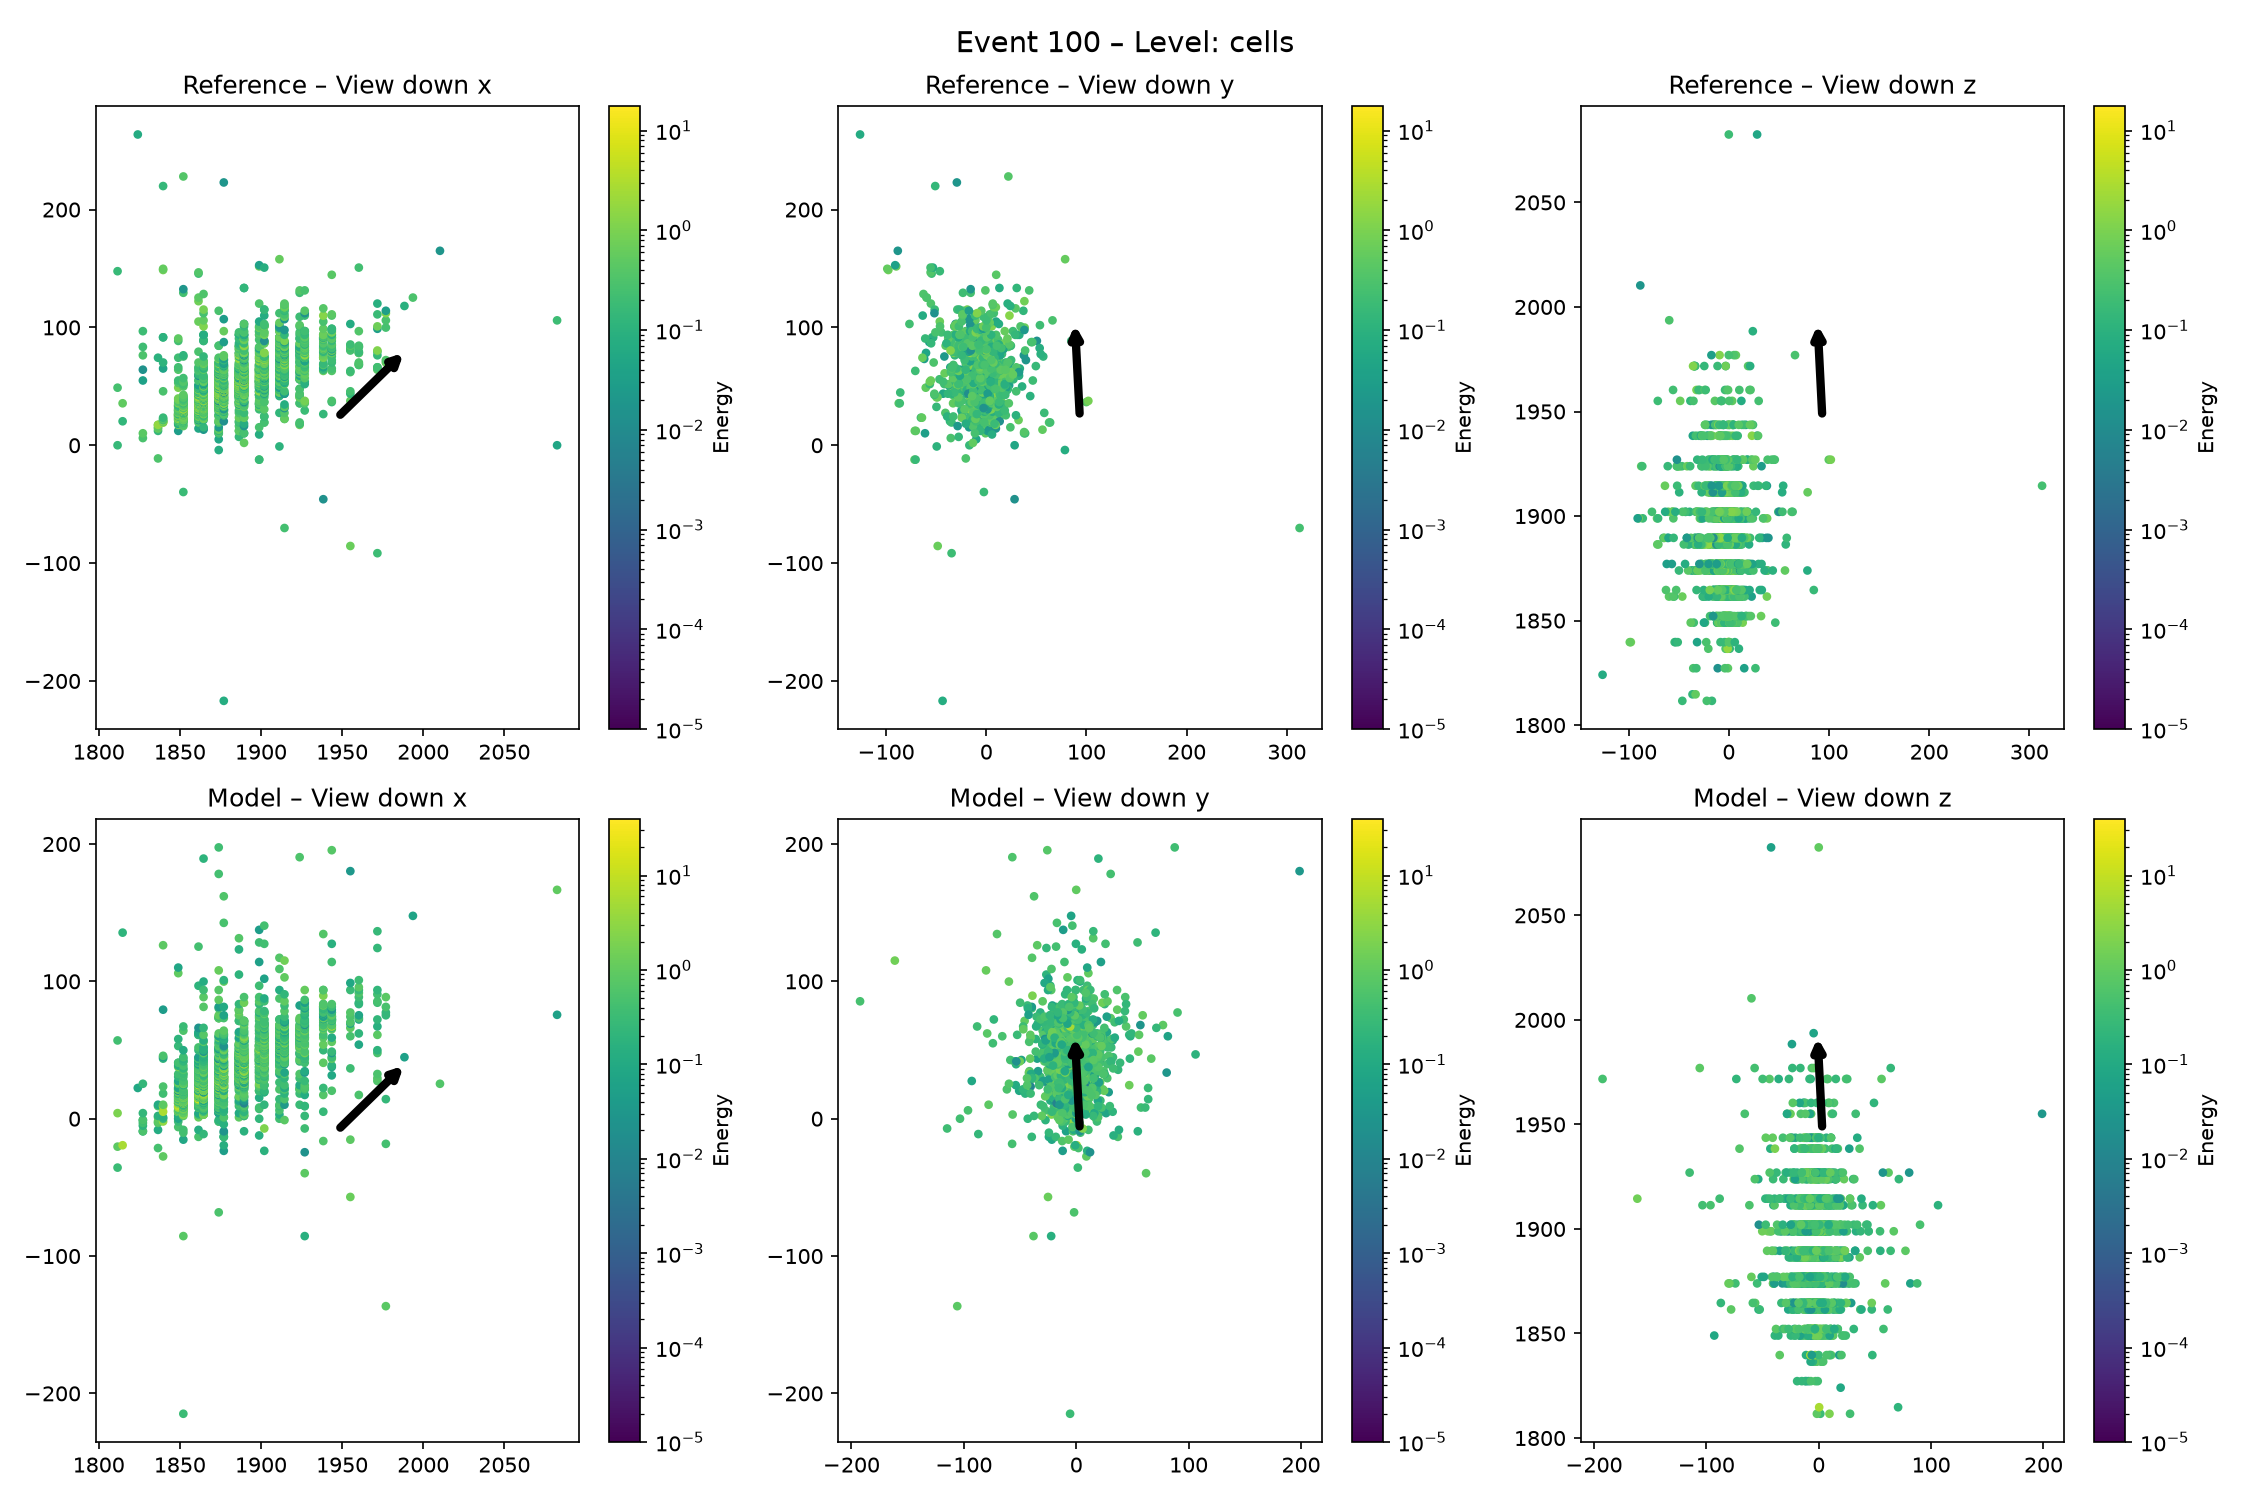

In [352]:
# took too long
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_3/2026_08_17__15_20_42/"  # sim
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_3/2026_08_17__15_21_09/"  # geant_4

# First ones that (kinda) worked
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_5/2026_08_17__15_19_32"  # padded photon 1, quite good, not amazing
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_5/2026_08_17__19_06_34/" # Padded_All 1, training ended, not that good

# Poor starting choices
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_4/2026_08_18__09_27_22/" # Padded photon 2
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_4/2026_08_18__09_27_42/" # Padded all 2

# latest with good starting choices
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_30/" # padded photons 3, best yet
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_34/" # padded all 3, best yet

# new distilled
log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__17_17_55/" # distilled from photons 3

summary_suffix = "_summary.npz"
summary_suffix = "_rescaled_energy_summary.npz"

all_model_paths = glob.glob(os.path.join(log_dir, "checkpoints", "*model.pt"))
print(f"Seen {len(all_model_paths)} models")
model_paths = []
for path in all_model_paths:
    if os.path.exists(path[:-3] + summary_suffix):
        model_paths.append(path)

print(f"Found {len(model_paths)} with summaries")
best_record = os.path.join(log_dir, "last_best_seen.txt")
if os.path.exists(best_record):
    with open(best_record, 'r') as ff:
        best_model_path = ff.read().strip()
    print(f"The best checkpoint is {best_model_path}")
else:
    print(f"Can't see a {best_record}, consider running scripts/generate_summary_plots_best.py")


dates = []
infos = []
configs = []
for path in model_paths:
    date = path.split('/')[-1][:19].replace('_', ' ')
    dates.append(date)
    config = Sampler.get_config_from_model_path(path)
    configs.append(config)
    ds_path = config['data']['dataset_path']
    info = f'{os.path.basename(ds_path).format("*")}'
    if path.endswith("_ema_model.pt"):
        info += " ema"
    infos.append(info)

n_infos = len(infos)
if len(infos) > 5:
    recent_dates = np.argsort(dates)
    #recent_dates = np.argsort(dates)[:2]
    select_dates = [recent_dates[0], recent_dates[n_infos//2], recent_dates[-2], recent_dates[-1]]
    if os.path.exists(best_record):
        for date in dates:
            if date in best_record:
                selected_dates.append(date)
                break
        else:
            print("Can't see the summary for the best record")
    
    print(dates)
    dates = [dates[j] for j in select_dates]
    print(dates)
    infos = [infos[j] for j in select_dates]
    model_paths = [model_paths[j] for j in select_dates]
    configs = [configs[j] for j in select_dates]

if len(set(infos)) < len(infos):
    for i, date in enumerate(dates):
        infos[i] = date[8:] + " " + info


for model_path in model_paths[::-1]:
    try:
        event_index = 100
        for level in ["data", "physical", "cells"]:
            display(Image(filename=f'{model_path[:-3]}_{level}_{event_index}.png'))
        break
    except FileNotFoundError:
        continue


In [353]:
ref_paths = ["/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/geant4_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/Padded_photon_full_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/Padded_All_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/sim-E1261AT600AP180-180_file_/pretest_Total1000_NoPick.npz",
            ]

for ref_path in ref_paths:
    ds_name = ref_path.split('/')[-2]
    if ds_name in configs[0]['data']['dataset_path']:
        break
else:
    print("Couldn't find the right ref path, do you need to make a new ref or add it to the list????")

    

sample_paths = [model_path.replace(".pt", summary_suffix) for model_path in model_paths]

ref = np.load(ref_path)
# first dimension is events
print(len(ref.keys()), {key:ref[key].shape for key in list(ref.keys())})

13 {'cond': (1000, 4), 'pca': (1000, 3), 'pca_top4': (1000, 3), 'event_energy': (1000,), 'cell_energies': (1000, 99), 'cell_energies_edges': (100,), 'radial_energy': (1000, 49), 'radial_energy_edges': (50,), 'layer_energies': (1000, 78), 'event_occupancies': (1000,), 'radial_occupancies': (1000, 49), 'radial_occupancies_edges': (50,), 'layer_occupancies': (1000, 78)}


In [354]:

def pca_to_angles(pca):
    """Convert pca direction vectors into (theta, phi) angles.

    theta is measured from the z axis, phi is the angle in the x-y plane.
    """
    x = pca[:, 0]
    y = pca[:, 1]
    z = pca[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return theta, phi


def augment_with_angles(data):
    """Return a dict copy of data with pca keys replaced by angle keys."""
    augmented = {}
    for key in data.keys():
        if "pca" in key and not key.endswith("_edges"):
            theta, phi = pca_to_angles(data[key])
            augmented[f"{key}_theta"] = theta
            augmented[f"{key}_phi"] = phi
        else:
            augmented[key] = data[key]
    return augmented


def bin_heights_and_edges(data, key):
    """Compute bin heights and edges for a given key."""
    values = data[key]
    edges_key = f"{key}_edges"
    if edges_key in data:
        edges = data[edges_key]
        heights = np.mean(values, axis=0)
    elif values.ndim == 1:
        ref_values = data[key]
        r_min, r_max = np.nanmin(ref_values), np.nanmax(ref_values)
        if abs(r_min - r_max) < 2:
            r_min -= 1
            r_max += 1
        r_min -= abs(r_min*0.1)
        r_max += abs(r_max*0.1)
        edges = np.linspace(r_min, r_max, 51)
        heights, _ = np.histogram(values, bins=edges)
    else:
        heights = np.mean(values, axis=0)
        edges = np.linspace(0, heights.shape[0], heights.shape[0] + 1)
    return heights, edges



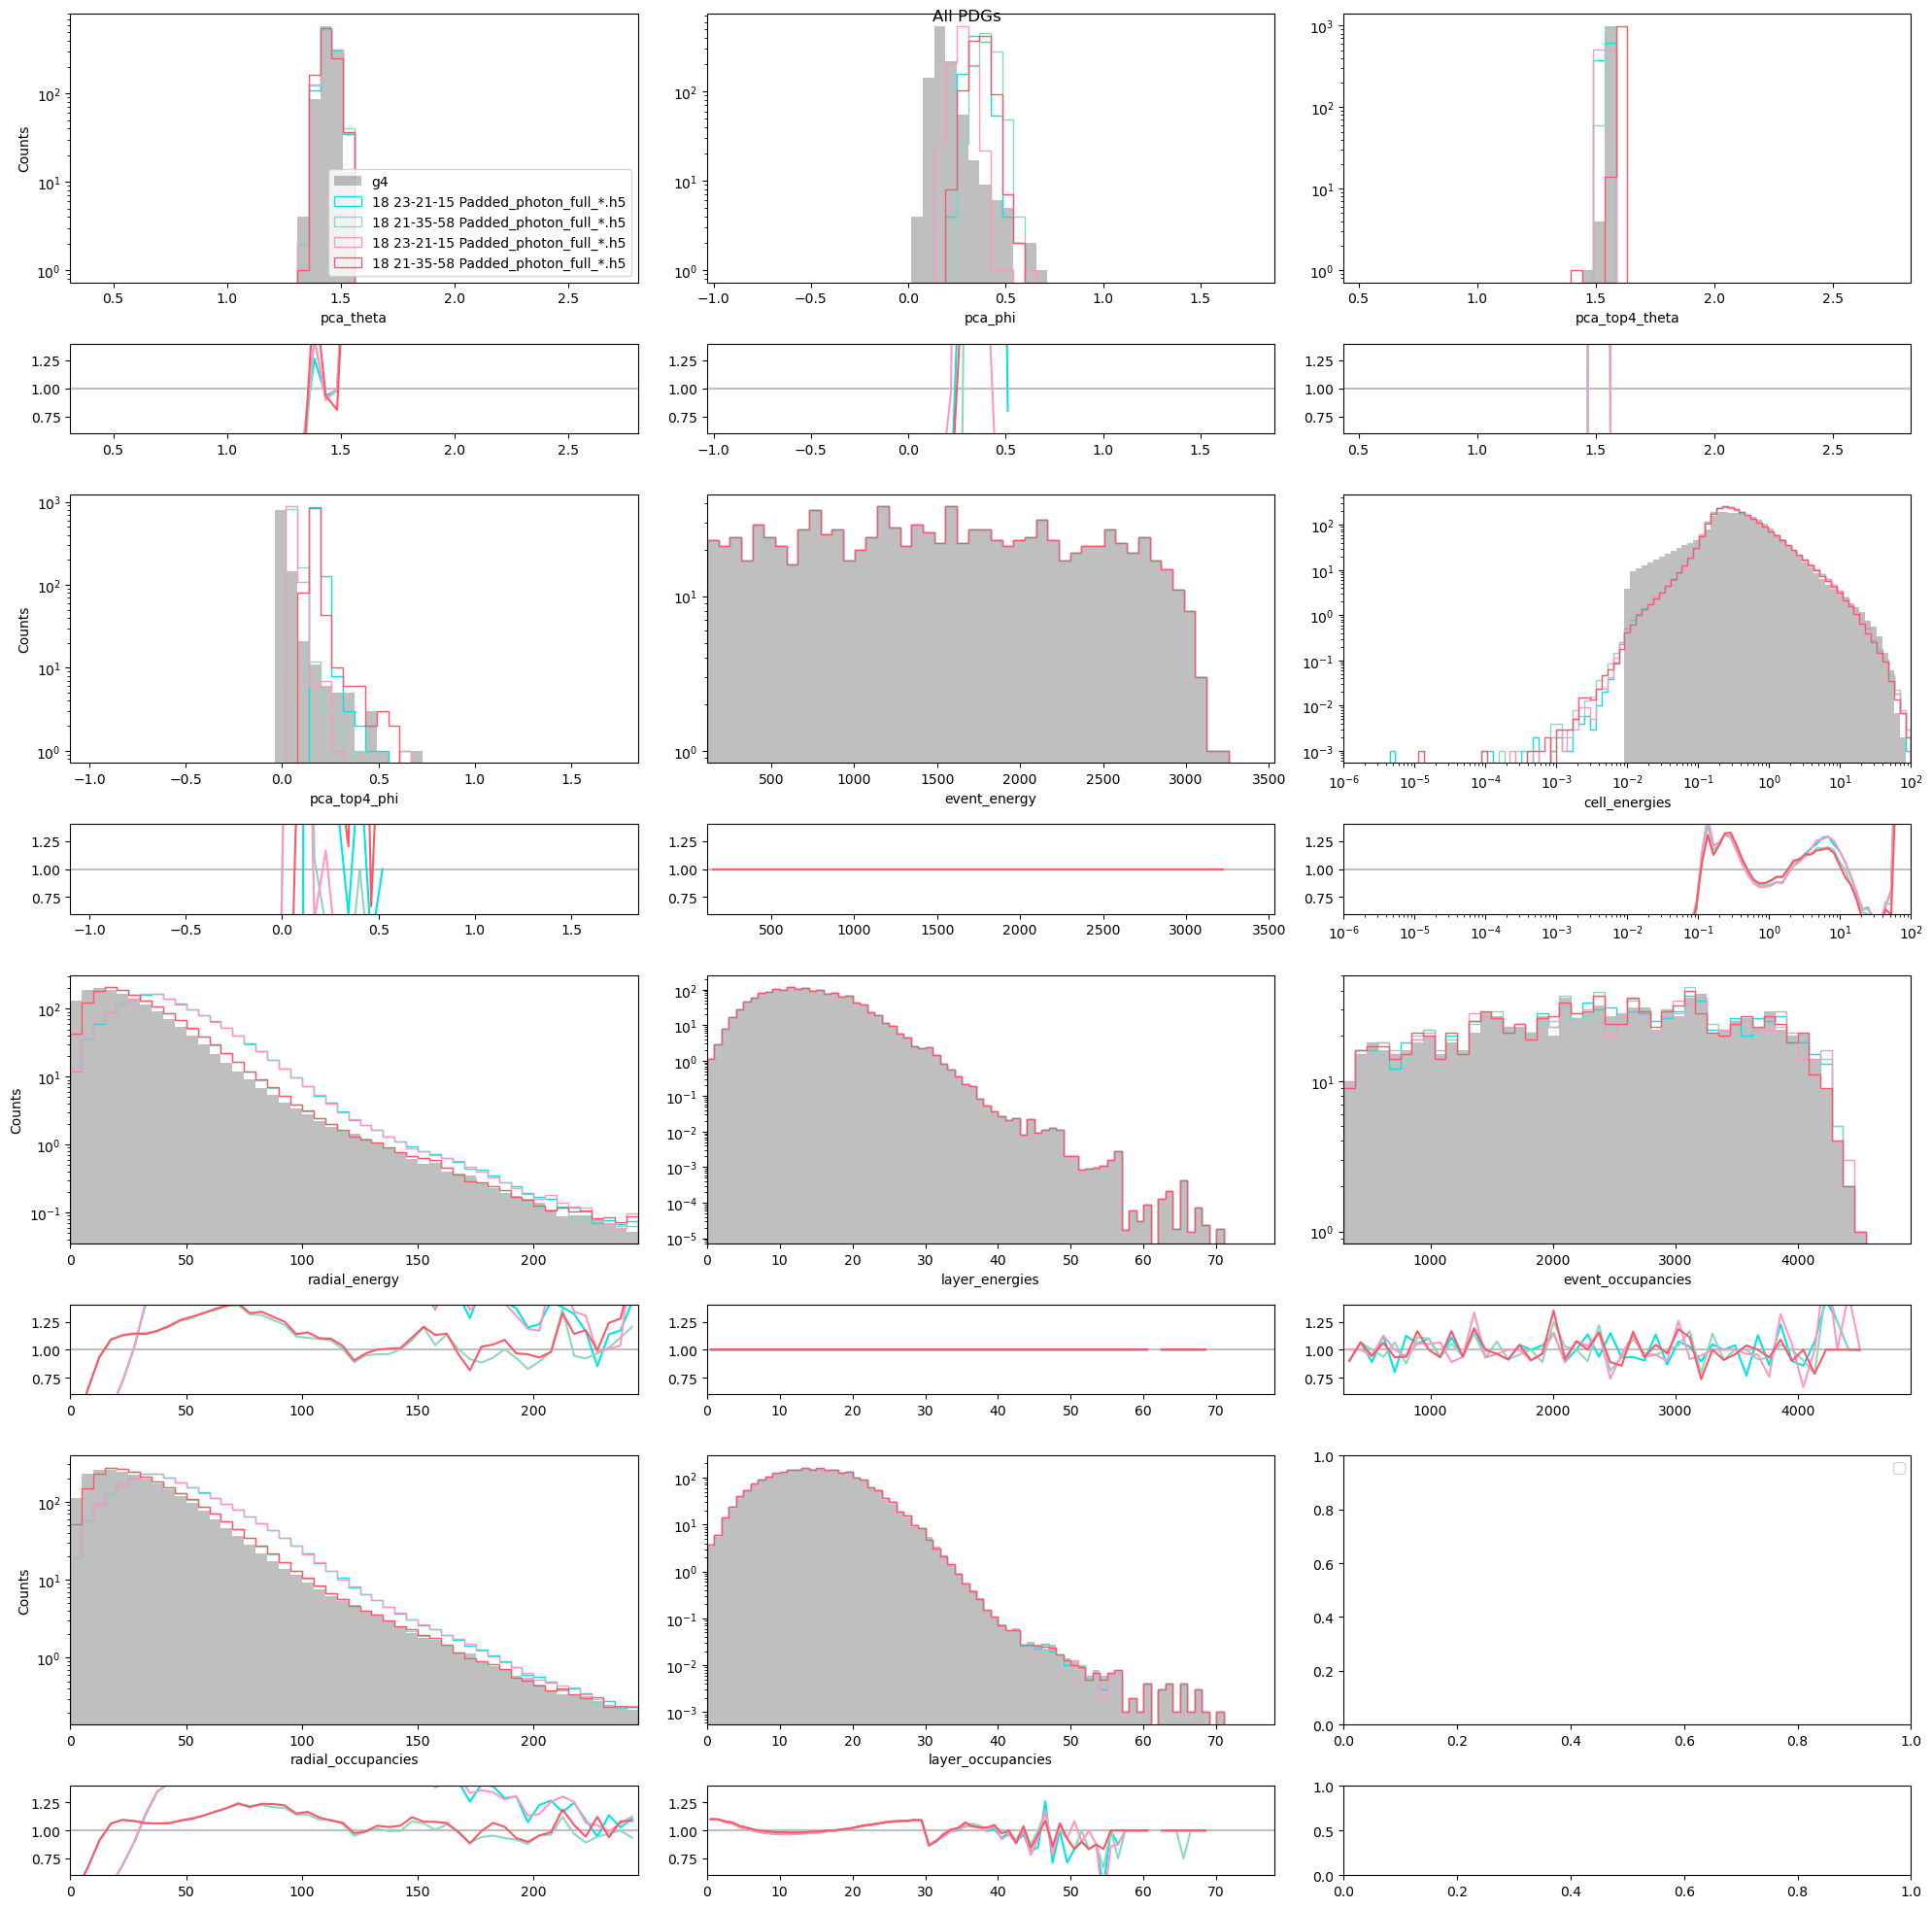

In [355]:

def plot_labels(x_labels, title):    
    ref_heights = []
    binnings = []
    for key in plot_keys:
        heights, edges = bin_heights_and_edges(a_ref, key)
        ref_heights.append(heights)
        binnings.append(edges)
    
    logx = ["cell_energies" in x_label for x_label in x_labels]
    logy = True
    
    ratio_plots = plotting.RatioPlots(x_labels, ref_heights, binnings, logx=logx, logy=logy)
    
    
    for i, sample_path in enumerate(sample_paths):
        sample = np.load(sample_path)
    
        a_sample = augment_with_angles(sample)
    
        sample_heights = [bin_heights_and_edges(a_sample, key)[0] for key in plot_keys]
        ratio_plots.add_comparison(sample_heights, label=infos[i], colour=plotting.nice_hex[0][i])
        
    ratio_plots.axes[0,0].legend()
    ratio_plots.fig.suptitle(title)
    ratio_plots.finalise()

a_ref = augment_with_angles(ref)

# collect the keys to plot (skip cond and any *_edges keys)
plot_keys = [
    key
    for key in a_ref.keys()
    if key != "cond" and not key.endswith("_edges")
    and not key.startswith("pdg_")
]
plot_labels(plot_keys, "All PDGs")


In [349]:
a_ref.keys()

dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell_energies_edges', 'radial_energy', 'radial_energy_edges', 'layer_energies', 'event_occupancies', 'radial_occupancies', 'radial_occupancies_edges', 'layer_occupancies', 'pdg_-11_cond', 'pdg_-11_pca_theta', 'pdg_-11_pca_phi', 'pdg_-11_pca_top4_theta', 'pdg_-11_pca_top4_phi', 'pdg_-11_event_energy', 'pdg_-11_cell_energies', 'pdg_-11_cell_energies_edges', 'pdg_-11_radial_energy', 'pdg_-11_radial_energy_edges', 'pdg_-11_layer_energies', 'pdg_-11_event_occupancies', 'pdg_-11_radial_occupancies', 'pdg_-11_radial_occupancies_edges', 'pdg_-11_layer_occupancies', 'pdg_11_cond', 'pdg_11_pca_theta', 'pdg_11_pca_phi', 'pdg_11_pca_top4_theta', 'pdg_11_pca_top4_phi', 'pdg_11_event_energy', 'pdg_11_cell_energies', 'pdg_11_cell_energies_edges', 'pdg_11_radial_energy', 'pdg_11_radial_energy_edges', 'pdg_11_layer_energies', 'pdg_11_event_occupancies', 'pdg_11_radial_occupancies', 'pdg_11_rad

['pdg_-11_pca_theta', 'pdg_-11_pca_phi', 'pdg_-11_pca_top4_theta', 'pdg_-11_pca_top4_phi', 'pdg_-11_event_energy', 'pdg_-11_cell_energies', 'pdg_-11_radial_energy', 'pdg_-11_layer_energies', 'pdg_-11_event_occupancies', 'pdg_-11_radial_occupancies', 'pdg_-11_layer_occupancies']
['pdg_11_pca_theta', 'pdg_11_pca_phi', 'pdg_11_pca_top4_theta', 'pdg_11_pca_top4_phi', 'pdg_11_event_energy', 'pdg_11_cell_energies', 'pdg_11_radial_energy', 'pdg_11_layer_energies', 'pdg_11_event_occupancies', 'pdg_11_radial_occupancies', 'pdg_11_layer_occupancies']
['pdg_22_pca_theta', 'pdg_22_pca_phi', 'pdg_22_pca_top4_theta', 'pdg_22_pca_top4_phi', 'pdg_22_event_energy', 'pdg_22_cell_energies', 'pdg_22_radial_energy', 'pdg_22_layer_energies', 'pdg_22_event_occupancies', 'pdg_22_radial_occupancies', 'pdg_22_layer_occupancies']


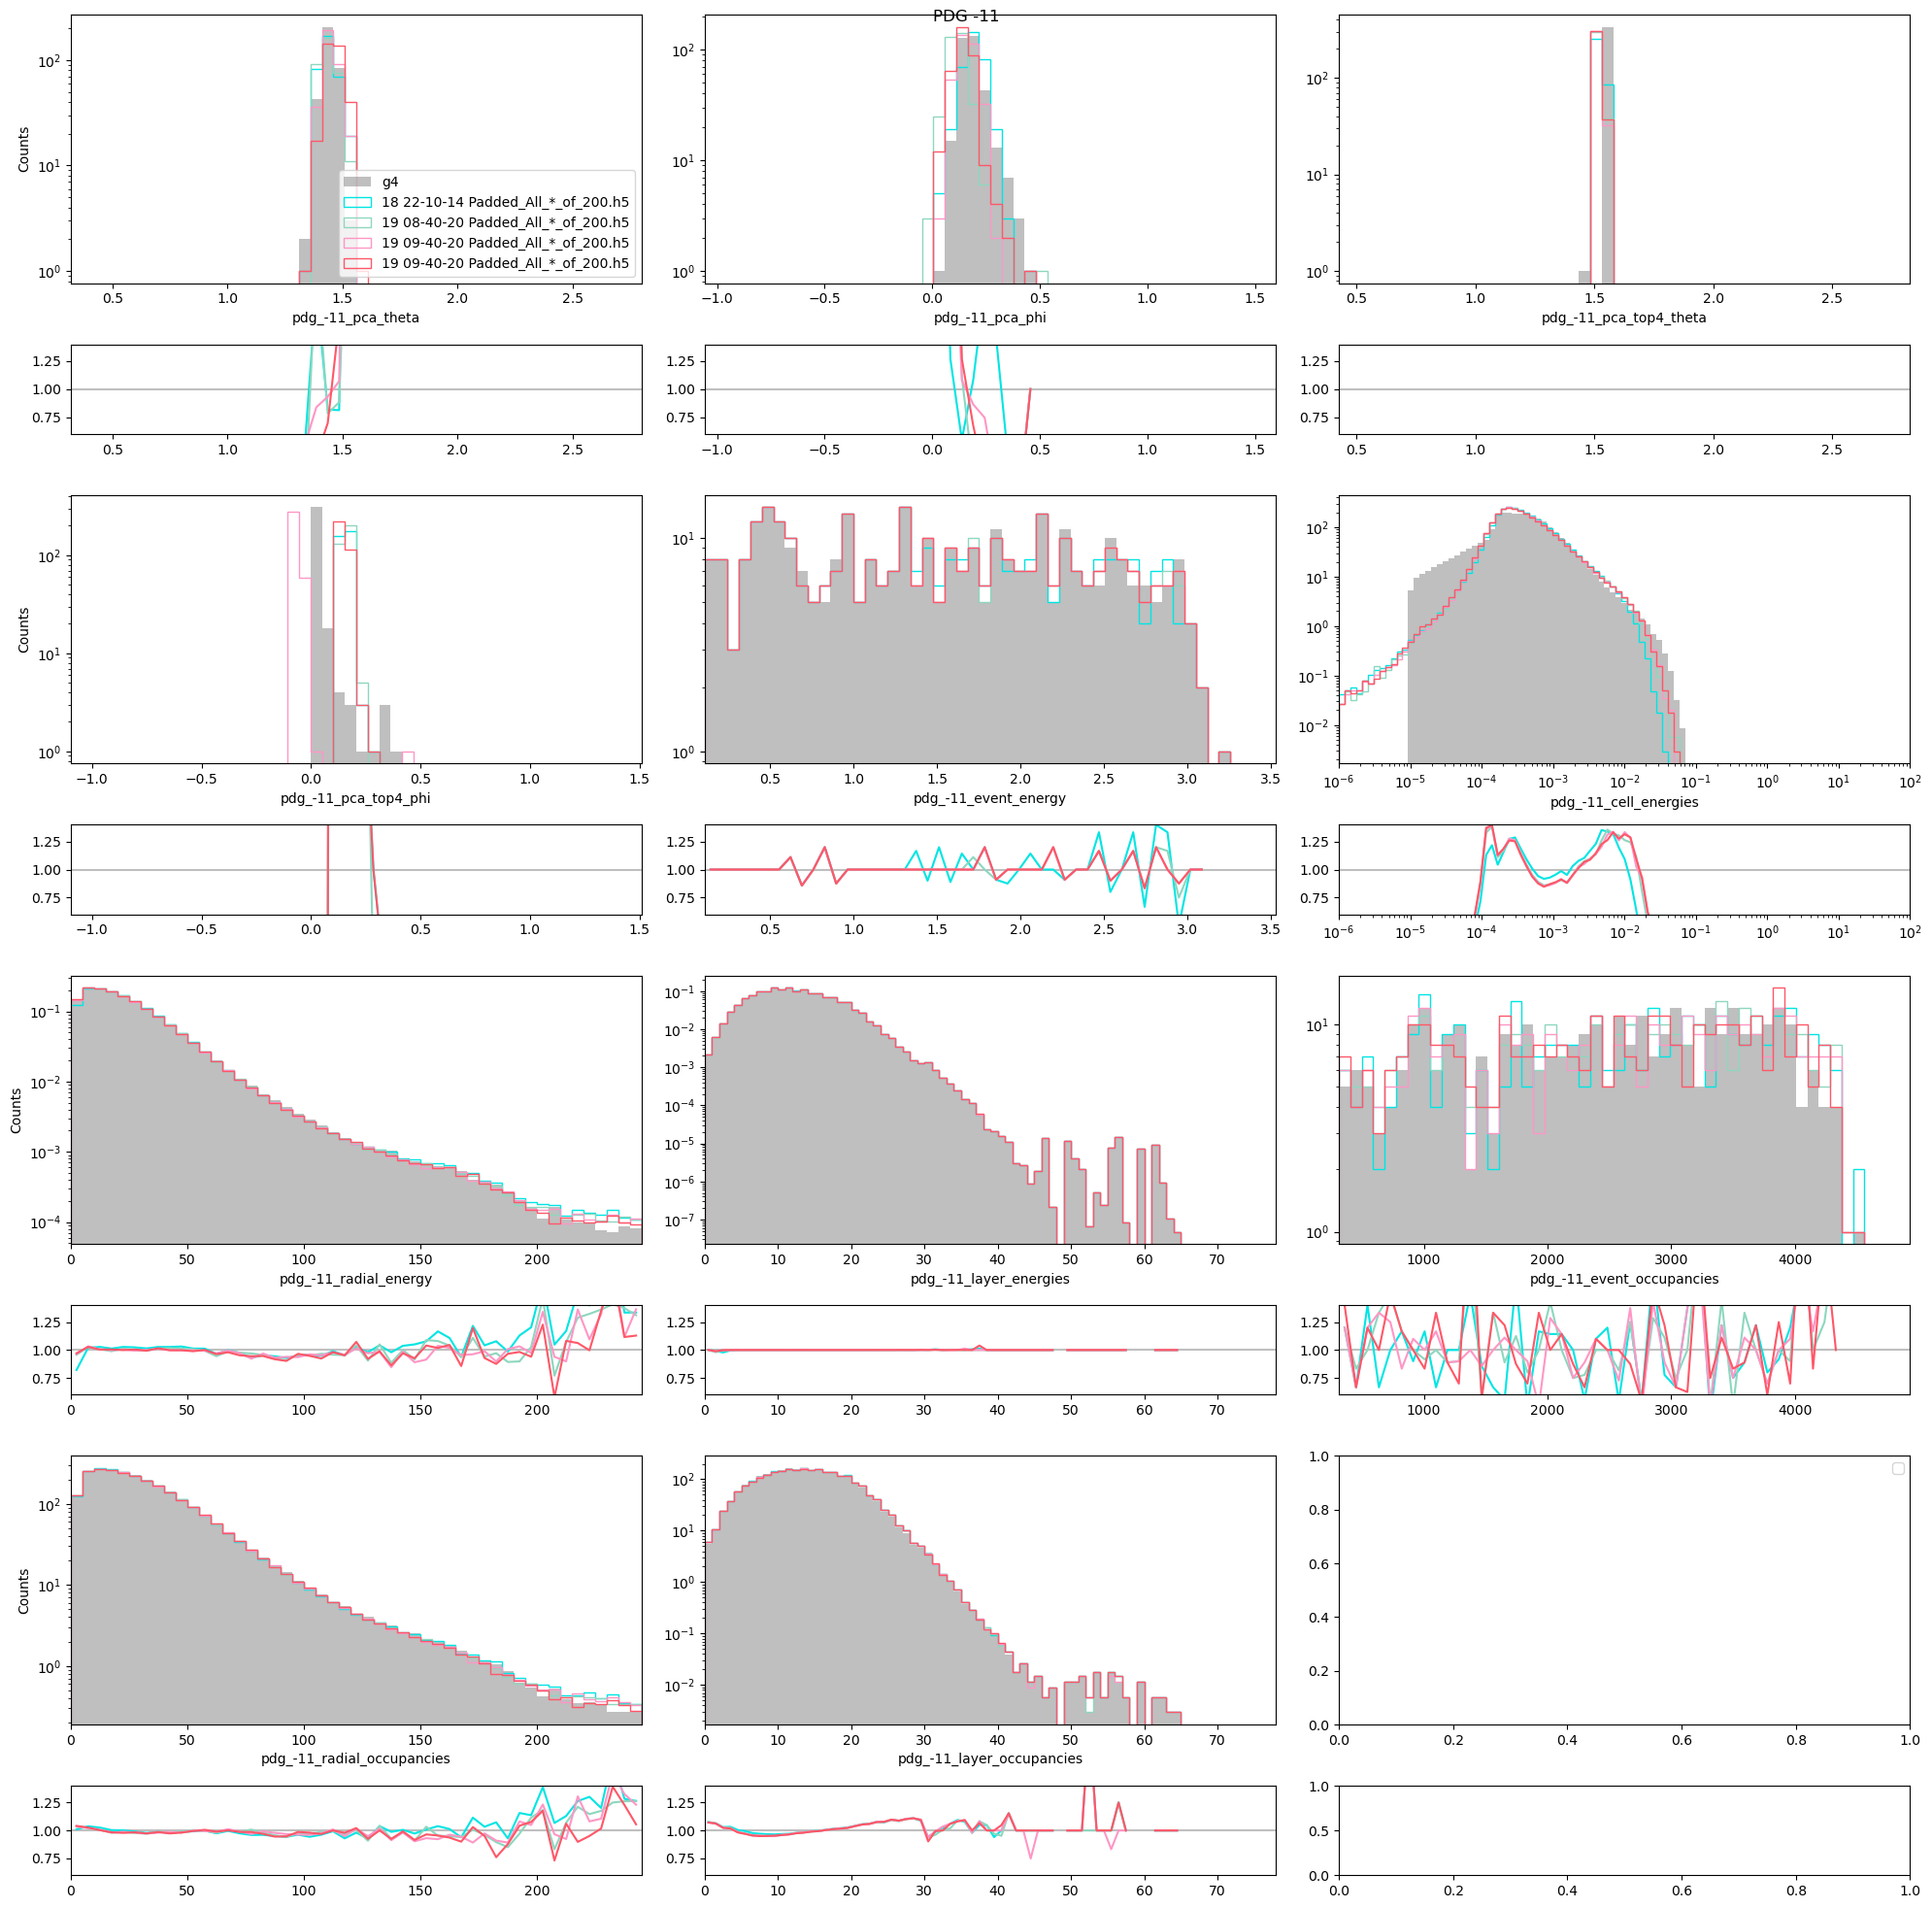

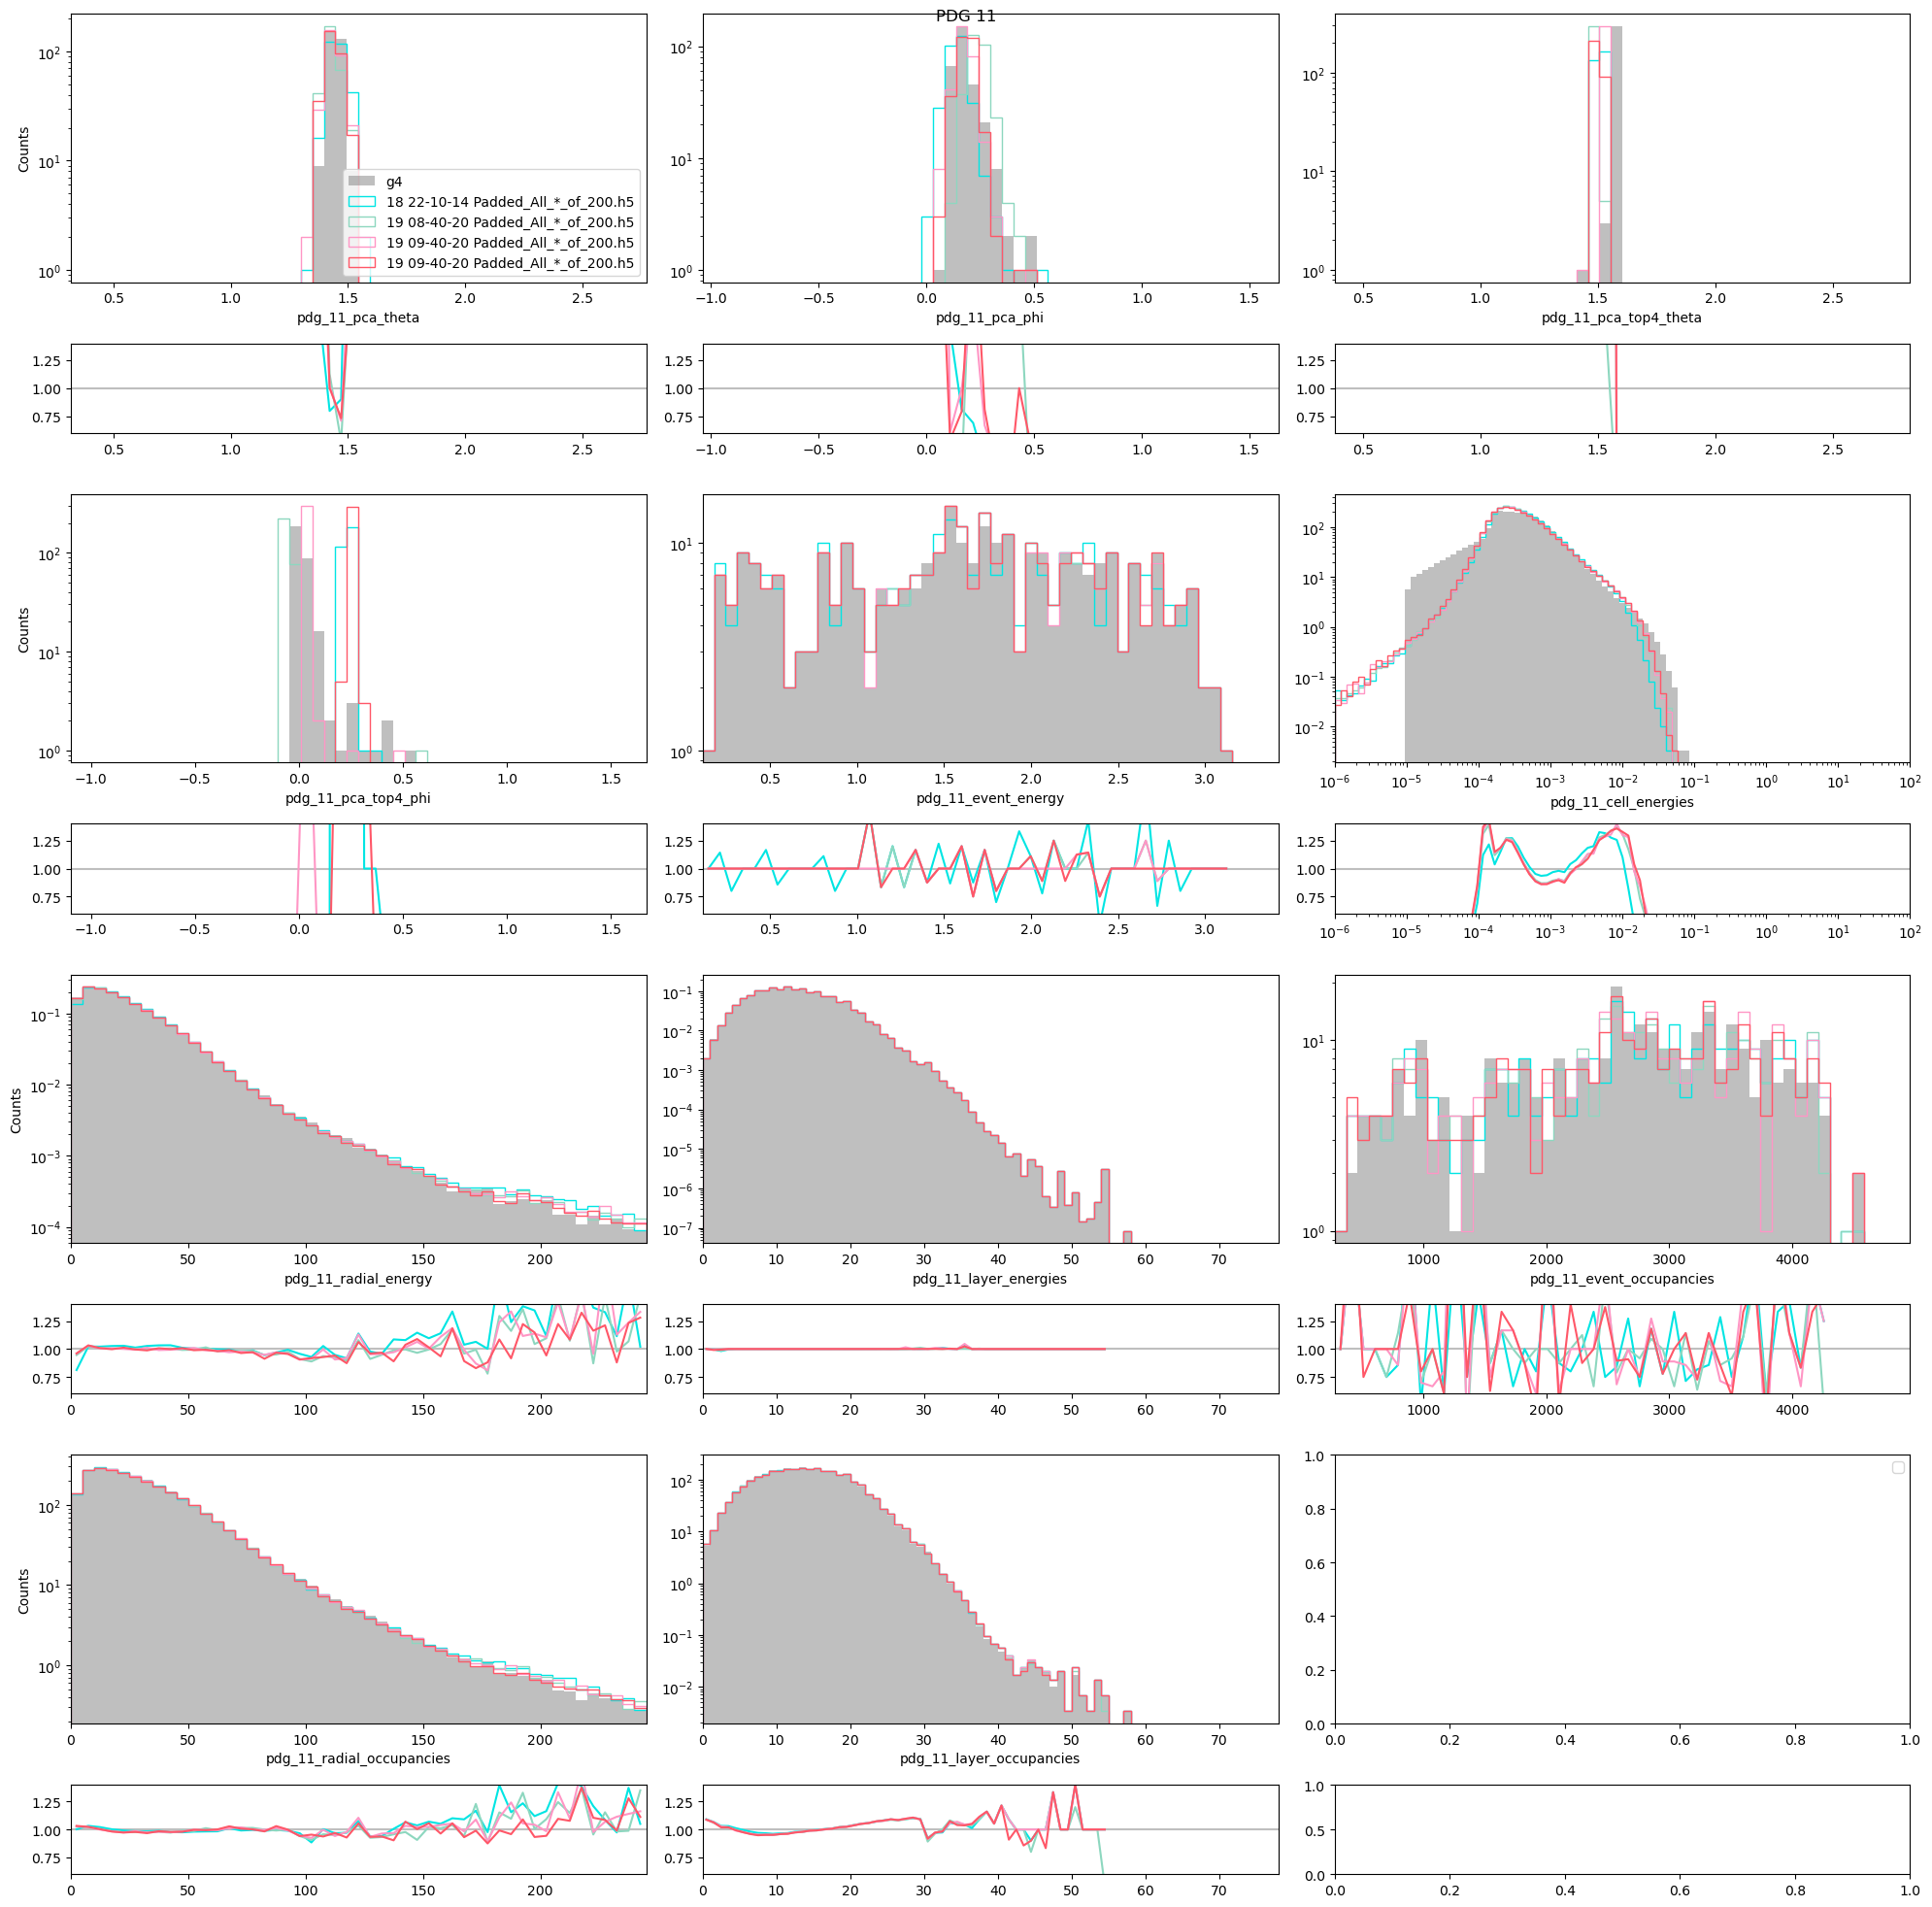

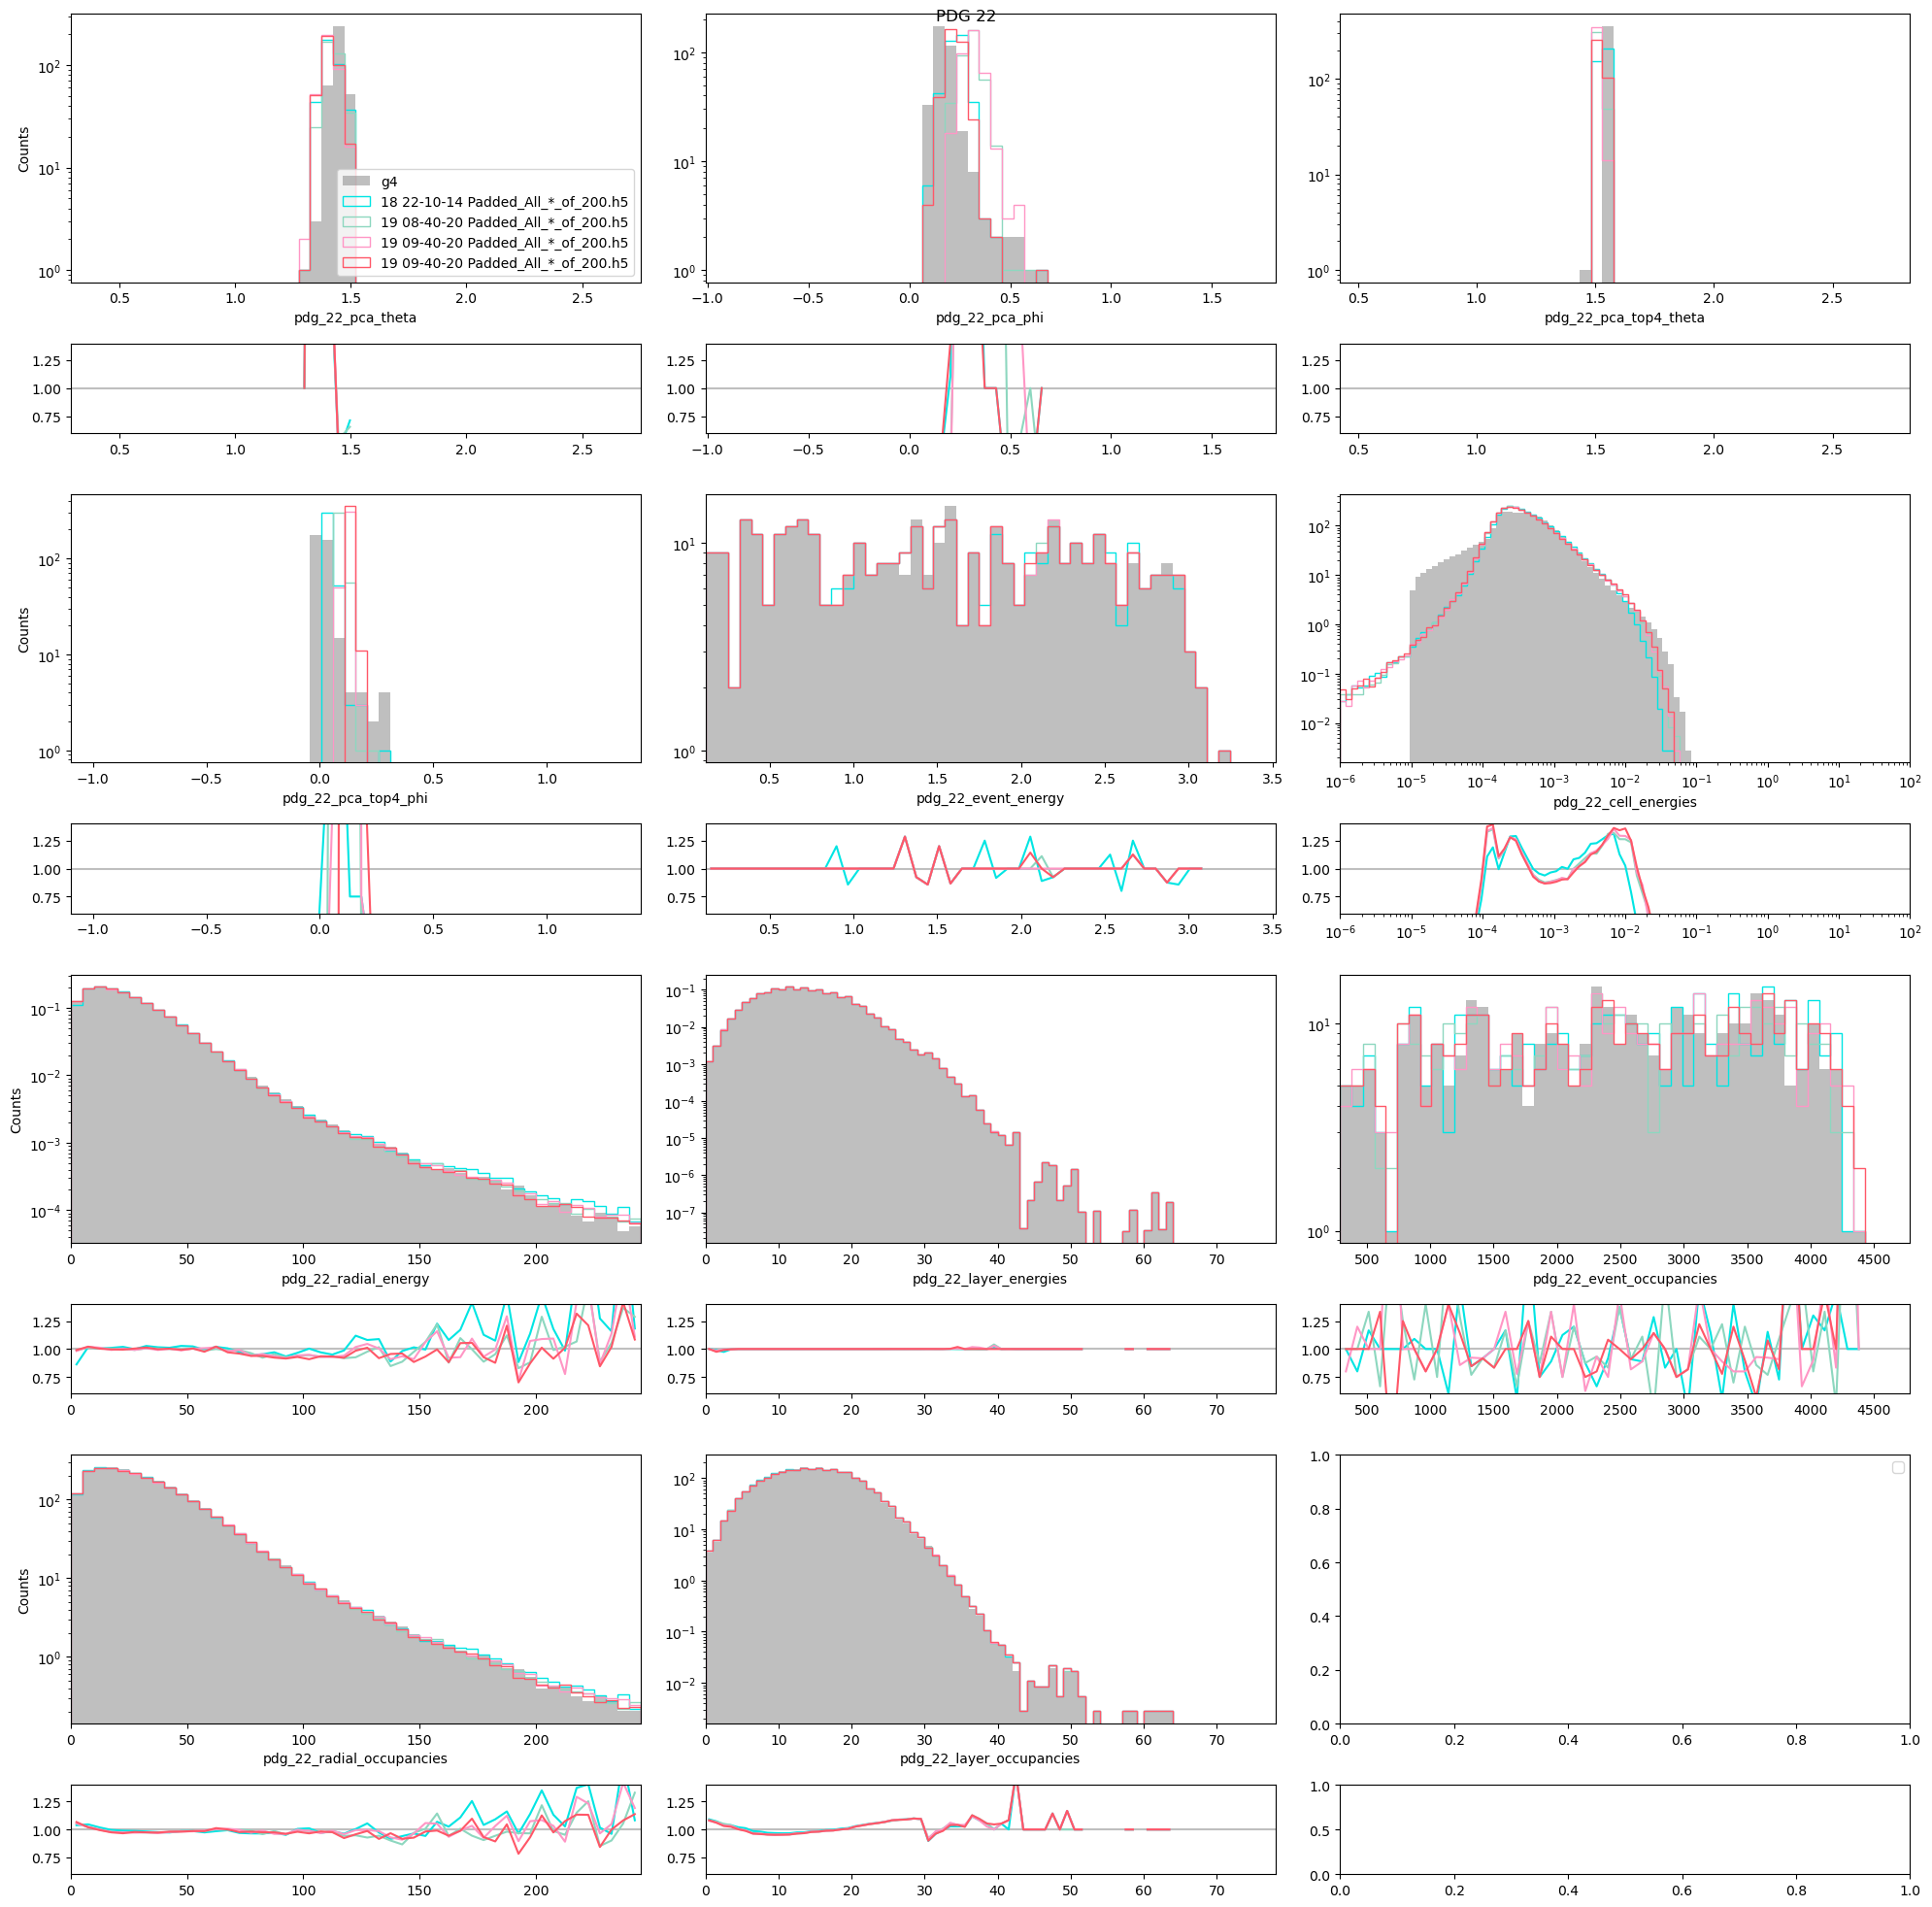

In [350]:
pdg_list = configs[0]["simulate_pdgs"]
if len(pdg_list)>1:
    for pdg in pdg_list:
        plot_keys = [
            key
            for key in a_ref.keys()
            if ("cond" not in key) and not key.endswith("_edges")
            and key.startswith(f"pdg_{pdg}")
        ]
        print(plot_keys)
        plot_labels(plot_keys, f"PDG {pdg}")


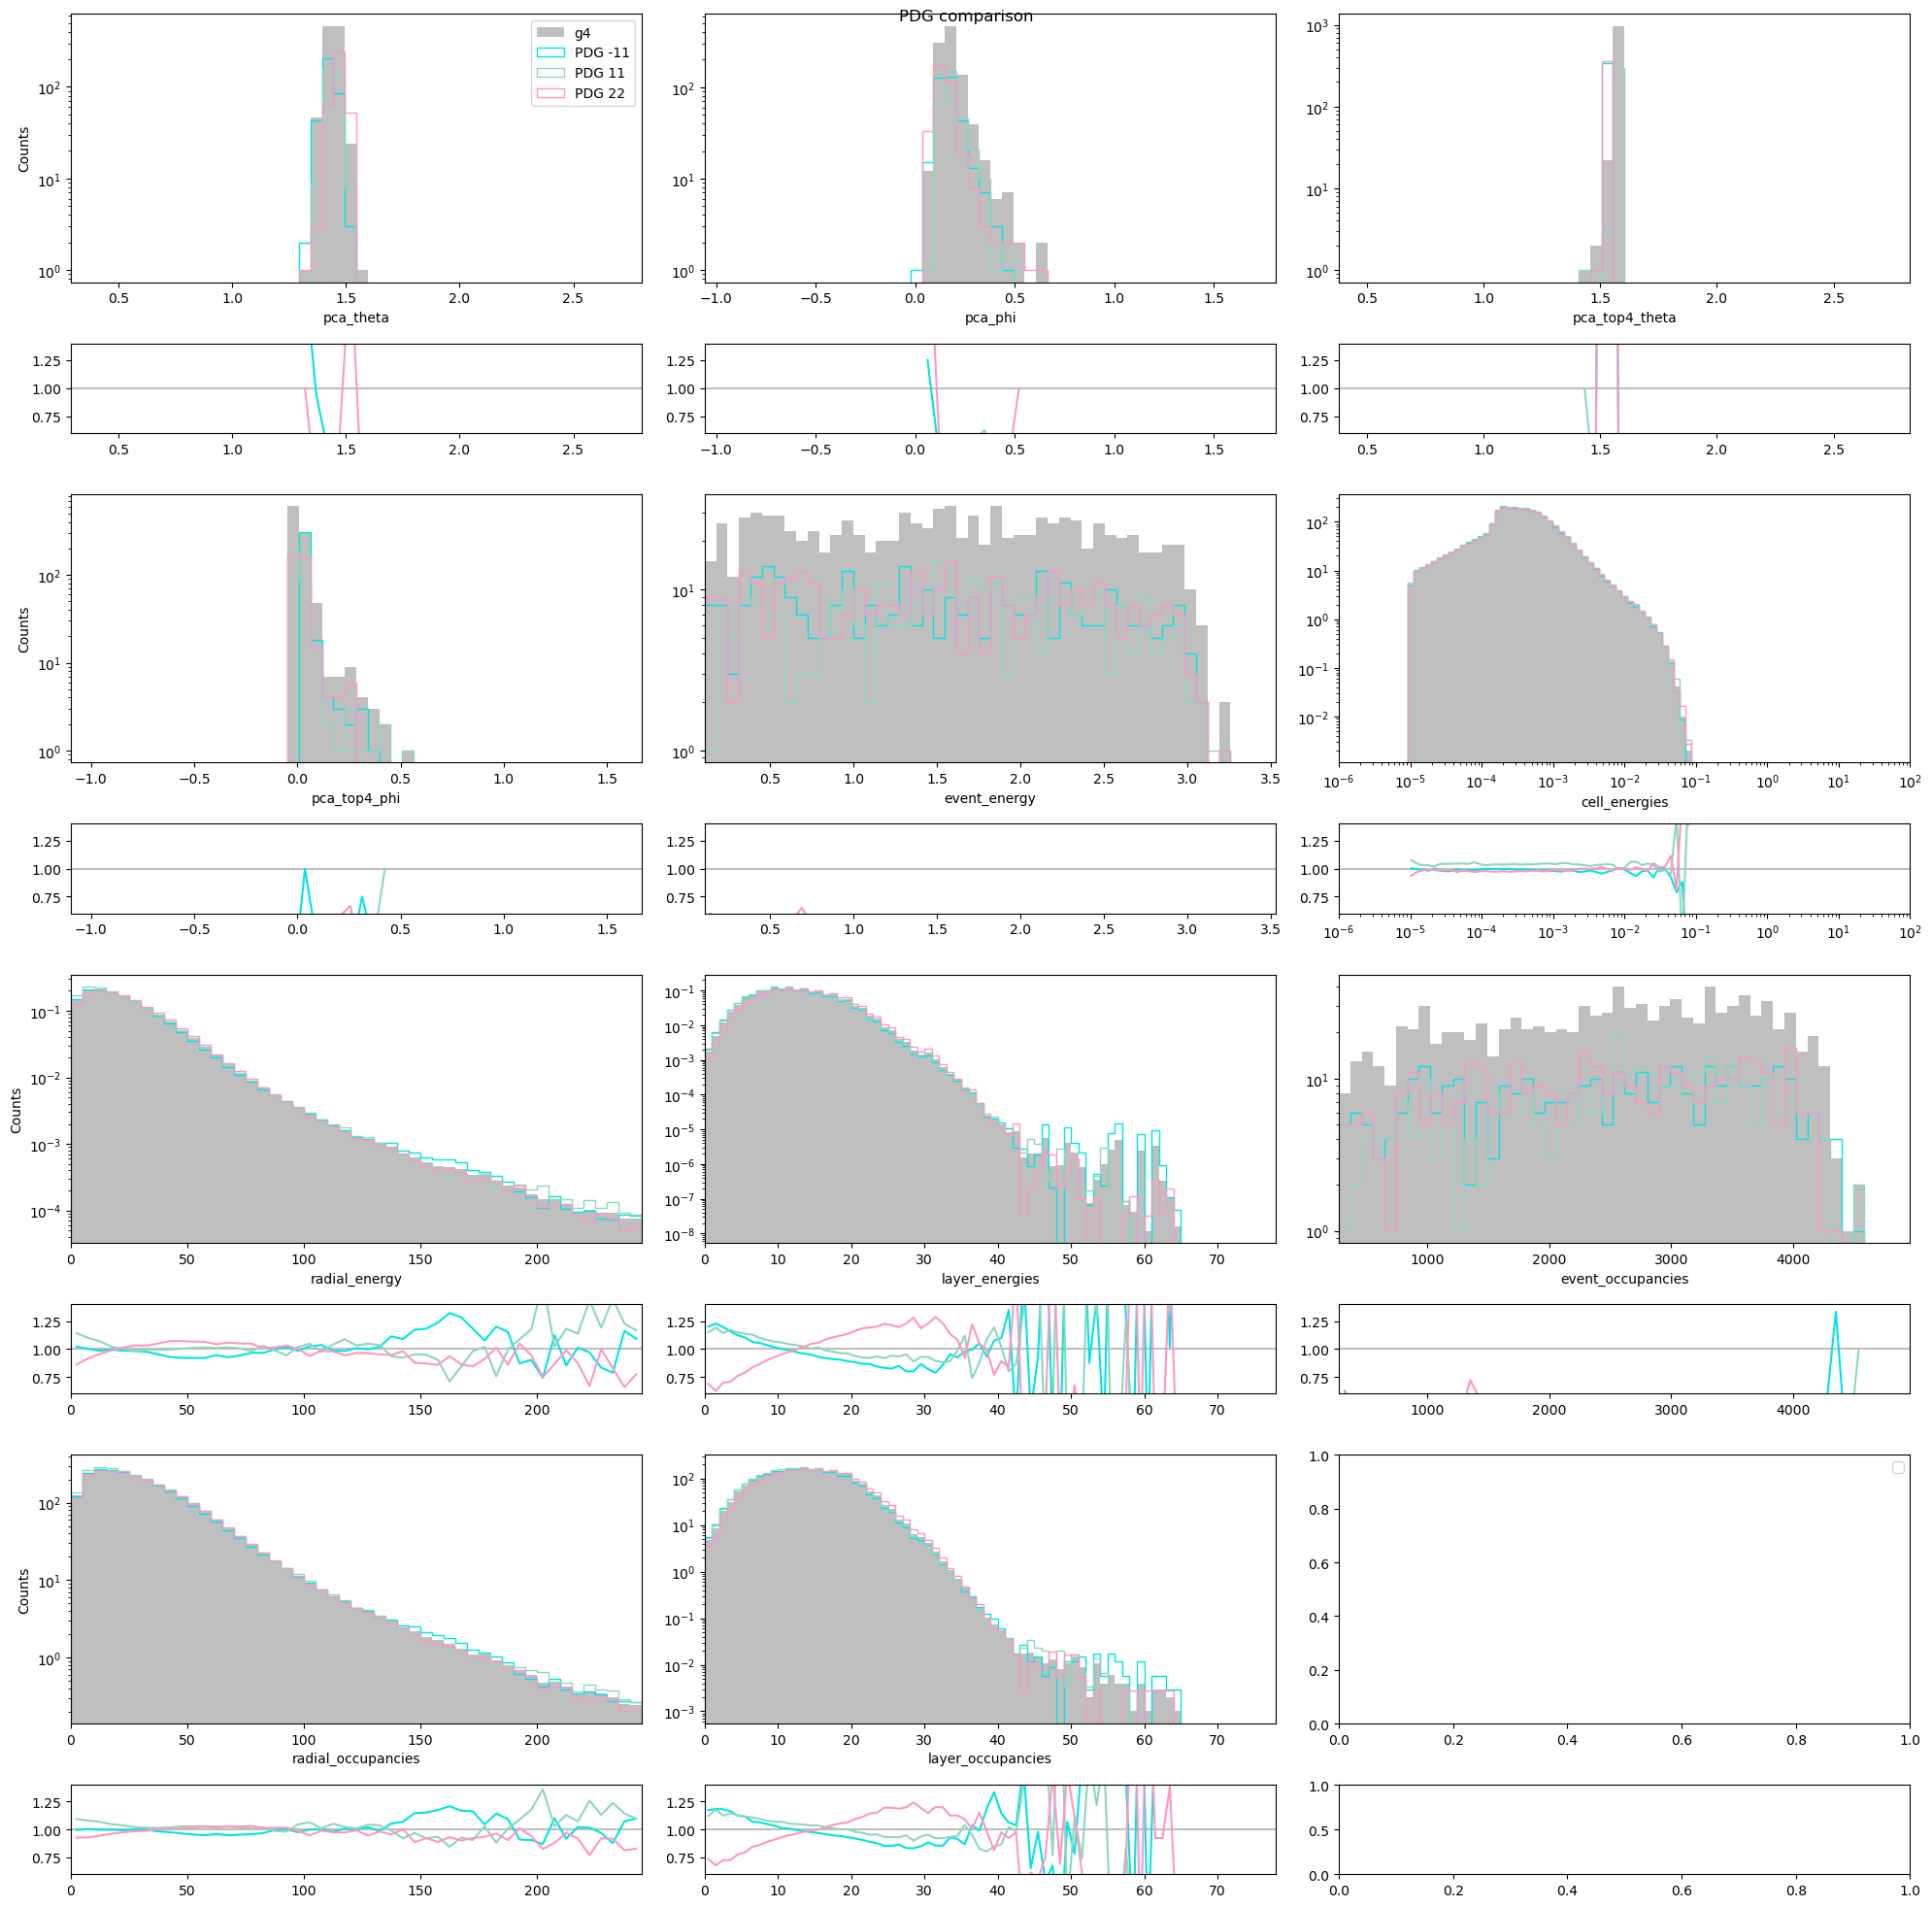

In [351]:
def rebin(heights, edges_old, edges_new):
    centers_old = 0.5*(edges_old[1:] + edges_old[:-1])
    heights_new = np.histogram(centers_old, bins=edges_new, weights=heights)[0]
    return heights_new


if len(pdg_list)>1:
    
    plot_keys = [
        key
        for key in a_ref.keys()
        if ("cond" not in key) and not key.endswith("_edges")
        and not key.startswith("pdg_")
    ]
    ref_heights = []
    binnings = []
    all_edges = {}
    for key in plot_keys:
        heights, edges = bin_heights_and_edges(a_ref, key)
        all_edges[key] = edges
        ref_heights.append(heights)
        binnings.append(edges)
    
    logx = [x_label == "cell_energies" for x_label in plot_keys]
    logy = True
    
    ratio_plots = plotting.RatioPlots(plot_keys, ref_heights, binnings, logx=logx, logy=logy)
    
    
    for i, pdg in enumerate(pdg_list):
        pdg_plot_keys = [
            key
            for key in a_ref.keys()
            if ("cond" not in key) and not key.endswith("_edges")
            and key.startswith(f"pdg_{pdg}")
        ]
        pdg_heights = []
        for key in pdg_plot_keys:
            my_heights, my_edges = bin_heights_and_edges(a_ref, key)
            old_key = '_'.join(key.split('_')[2:])
            heights = rebin(my_heights, my_edges, all_edges[old_key])
            pdg_heights.append(heights)
    
        ratio_plots.add_comparison(pdg_heights, label=f"PDG {pdg}", colour=plotting.nice_hex[0][i])
        
    ratio_plots.axes[0,0].legend()
    ratio_plots.fig.suptitle("PDG comparison")
    ratio_plots.finalise()
